In [6]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


In [23]:

def flatten(i, o):
  im = Image.open(i)
  m = np.asarray(im)
  i, j = np.mgrid[:2000, :2000]

  sx, sy = i.shape[0], i.shape[1]
  cx, cy = sx / 2, sy / 2
  R = i.shape[0] / 2 / 2.5
  xrel, yrel = (i - cx) / R, (j - cy) / R


  r = np.sqrt(xrel * xrel + yrel * yrel)
  band = np.remainder(r, 2) > 1
  r = r % 1 - band * r % 1 * 2

  alpha = np.atan2(yrel, xrel)
  alpha = (alpha + band * np.pi)
  x = ((alpha + np.pi) / np.pi / 2) % 1 * m.shape[1]
  y = r * m.shape[0]

  n = np.zeros_like(i)
  n = m[np.minimum(y, m.shape[0]-1).astype('i4'), np.minimum(x, m.shape[1]-1).astype('i4')]
  im2 = Image.fromarray(n)
  im2.save(o)

flatten("model/6K Earth Textures/Earth_Clouds_6K.png", 'model/6K Earth Textures/Earth_Clouds_flat.png')
flatten("model/6K Earth Textures/Earth_Col_6K.png", 'model/6K Earth Textures/Earth_Col_flat.png')
flatten("model/6K Earth Textures/Earth_Emit_6K.png", 'model/6K Earth Textures/Earth_Emit_flat.png')
flatten("model/6K Earth Textures/Earth_Nor_6K.png", 'model/6K Earth Textures/Earth_Nor_flat.png')
flatten("model/6K Earth Textures/Earth_Rough_6K.png", 'model/6K Earth Textures/Earth_Rough_flat.png')

In [5]:
p = np.linspace(0, 1, 5000)

k = 0
for k in np.linspace(-1, 1, 10):
  px, py, pz = 300e3 - p * 400e3, Re / 2, (k + p * 0.1) * Re
  plt.plot(x(px, py, pz), h(px, py, pz))
plt.axis('equal')
plt.show()

NameError: name 'plt' is not defined

In [4]:
import sympy
# (radial distance, polar angle, azimuthal angle): (r, theta, phi), (r, θ, ϕ)
r, theta, phi = sympy.symbols('r theta phi')
R = sympy.symbols('R')
x, y, z = sympy.symbols('x y z')
dx, dy, dz, dr, dtheta, dphi = sympy.symbols('dx dy dz dr dθ dϕ')

x = R * sympy.exp(r) * sympy.sin(theta) * sympy.cos(phi)
y = R * sympy.exp(r) * sympy.sin(theta) * sympy.sin(phi)
z = R * sympy.exp(r) * sympy.cos(theta)

dx = R * (sympy.exp(r) * sympy.sin(theta) * sympy.cos(phi) * dr + sympy.exp(r) * sympy.cos(theta) * sympy.cos(phi) * dtheta - sympy.exp(r) * sympy.sin(theta) * sympy.sin(phi) * dphi)
dy = R * (sympy.exp(r) * sympy.sin(theta) * sympy.sin(phi) * dr + sympy.exp(r) * sympy.cos(theta) * sympy.sin(phi) * dtheta + sympy.exp(r) * sympy.sin(theta) * sympy.cos(phi) * dphi)
dz = R * (sympy.exp(r) * sympy.cos(theta) * dr - sympy.exp(r) * sympy.sin(theta) * dtheta)

(dx ** 2 + dy ** 2 + dz ** 2).simplify()

R**2*(dr**2 + dθ**2 + dϕ**2*sin(theta)**2)*exp(2*r)

In [149]:
# normal spherical coordinates
x = r * sympy.sin(theta) * sympy.cos(phi)
y = r * sympy.sin(theta) * sympy.sin(phi)
z = r * sympy.cos(theta)

dx =  sympy.sin(theta) * sympy.cos(phi) * dr + r * sympy.cos(theta) * sympy.cos(phi) * dtheta - r * sympy.sin(theta) * sympy.sin(phi) * dphi
dy =  sympy.sin(theta) * sympy.sin(phi) * dr + r * sympy.cos(theta) * sympy.sin(phi) * dtheta + r * sympy.sin(theta) * sympy.cos(phi) * dphi
dz =  sympy.cos(theta) * dr - r * sympy.sin(theta) * dtheta

(dx ** 2 + dy ** 2 + dz ** 2).simplify()

dr**2 + dθ**2*r**2 + dϕ**2*r**2*sin(theta)**2

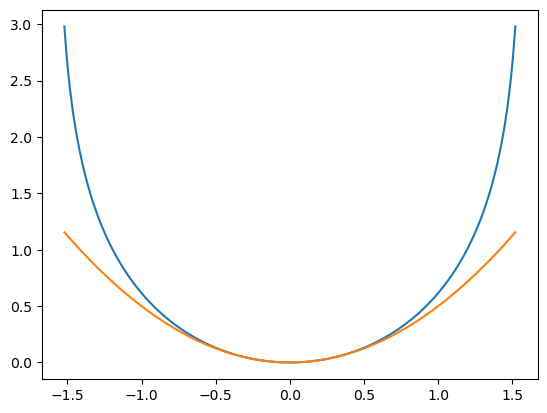

In [4]:
from matplotlib import pyplot as plt

b = 0
theta = np.linspace(-1.52, 1.52, 500)
r = b - np.log(np.cos(theta))
plt.plot(theta, r)
plt.plot(theta, theta ** 2 / 2)

-1.5707963249869463
-1.5707963204326227
-1.570796304405716
-1.5707962480061775
-1.5707960495331954
-1.5707953510961956
-1.5707928932591768
-1.5707842439997393
-1.5707538067948839
-1.5706466966486226
-1.5702697703146165
-1.5689433455080102
-1.5642755444289684
-1.5478474945266032
-1.4899572336119034
-1.2826584765927516
0.0
1.2826584765927516
1.4899572336119034
1.5478474945266032
1.5642755444289684
1.5689433455080102
1.5702697703146165
1.5706466966486226
1.5707538067948839
1.5707842439997393
1.5707928932591768
1.5707953510961956
1.5707960495331954
1.5707962480061775
1.570796304405716
1.5707963204326227
1.5707963249869463


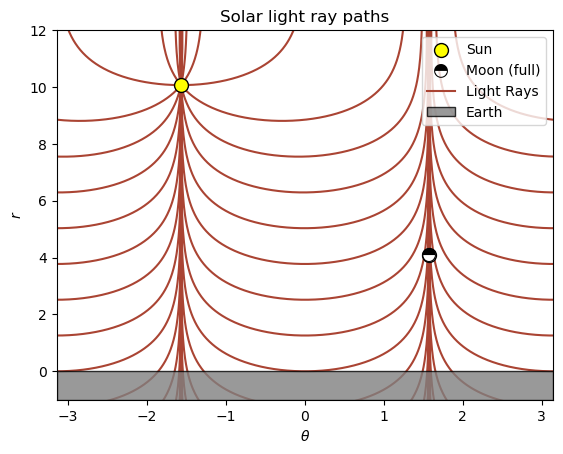

In [158]:

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
sun_r = np.log(150e6 / 6378)
moon_r = np.log(380e3 / 6378)

light_col = '#aa4433'
# for i, r_ in enumerate([-1e6, -100000, -20000, -1000, -100, -10, -1, 0, 1, 10, 100, 1000, 10000, 100000, 1,6]):
#   c = np.arctan(r_)
for i, r_ in enumerate(np.linspace(-sun_r*2, sun_r*2, 8*4+1)):
  c = np.arccos(np.exp(-np.abs(r_))) * np.sign(r_)
  print(c)
  b = 0
  eps = 1e-5
  theta = np.linspace(-np.pi / 2 + eps, np.pi / 2 - eps, 500)
  r = np.log(np.cos(c)) - np.log(np.cos(theta))
  x = theta - c - np.pi / 2
  y = r + sun_r
  plt.plot(x, y, c=light_col)
  plt.plot(x + np.pi * 2, y, c=light_col)


plt.scatter([-np.pi/2], [sun_r], c='yellow', s=100, marker='o', edgecolors='black', zorder=2, label='Sun')
plt.scatter([np.pi/2], [moon_r], c='black', s=100, marker='$\u25D3$', edgecolors='none', zorder=3, label='Moon (full)')
plt.scatter([np.pi/2], [moon_r], c='white', s=100, marker='o', edgecolors='black', zorder=2)
plt.plot([], [], c=light_col, label='Light Rays')
plt.axhspan(-1, 0, fc='gray', ec='black', alpha=0.8, label='Earth', zorder=4)
plt.xlim(-np.pi, np.pi)
plt.ylim(-1, 12)
plt.ylabel('$r$')
plt.xlabel('$\\theta$')
plt.legend(loc=1)
plt.title('Solar light ray paths')
plt.savefig('solar-light-rays.png', dpi=180, bbox_inches='tight')

np.float64(1.5301840434189435)

array([0.        , 0.04143887, 0.13693183, 0.29608678, 0.45524172,
       0.48707271])

array([ 3.20395962,  1.77215014,  0.79054808,  0.19196517,  0.00500836,
       -0.        ])

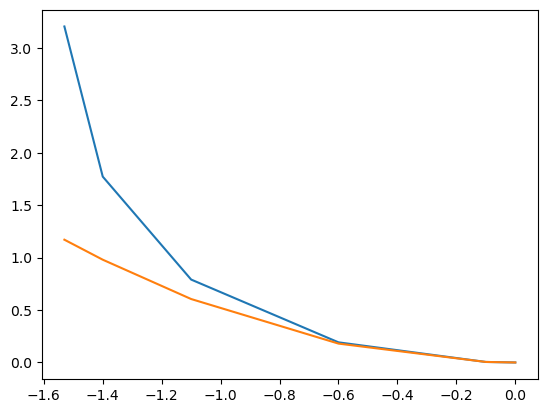

In [22]:

AU = 150000000
Ds = np.log(AU / Re) / np.pi

x0 = np.arccos(np.exp(-Ds))


display(x0)
theta = np.array([-x0, -1.4, -1.1, -0.6, -0.1, 0])
r = -np.log(np.cos(theta))
plt.plot(theta, r)
plt.plot(theta, theta ** 2 / 2)
display((theta - theta[0]) / np.pi, r)

In [9]:
Re*np.exp(1*np.pi/20000)

np.float64(6379.0019325867715)

In [15]:
np.log(150e6 / 6378) / np.pi * 20e3

np.float64(64079.19239936453)